In [27]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import HuberRegressor



In [2]:
df = pd.read_csv('../data/dataset_clean_robust.csv')
df

,R1301A,R1301B,R1301C,R1303A,R1303B,R1303C,R1305A,R1305B,R1305C,R1305D,...,R1103JK7_3,R1103JK7_4,R1103JK7_5,R1103JK7_6,R1103JK7_7,R1103JK7_9,index_k_raw,URUT,index_k,WEIGHT
0,0.0,0.0,-1.0,3.0,0.0,3.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,70,1,62.31,210.870377
1,0.0,1.0,0.0,3.0,0.0,1.0,3.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,70,2,72.21,210.870377
2,0.0,0.0,0.0,0.0,0.0,3.0,3.0,0.0,1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,70,3,70.80,210.870377
3,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,80,4,72.89,210.870377
4,0.0,0.0,0.0,3.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,80,5,72.34,210.870377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74679,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90,74600,76.08,700.200012
74680,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90,74618,67.29,399.394104
74681,0.0,1.0,0.0,2.0,0.0,2.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90,74671,64.13,341.872620
74682,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,-2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,90,74673,71.23,341.872620


In [4]:
# Fitur dan target
y = df['index_k']
sample_weight = df['WEIGHT']
sample_weight = sample_weight / np.mean(sample_weight)
X = df.drop(columns=['index_k_raw', 'WEIGHT', 'URUT', 'index_k'])

X_train, X_test, y_train, y_test, weight_train, weight_test = train_test_split(
    X, y, sample_weight, test_size=0.3, random_state=42
)

In [5]:
# Train the model (using your Random Forest Regressor)
model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [6]:
# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)


In [7]:
# Calculate residuals
residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

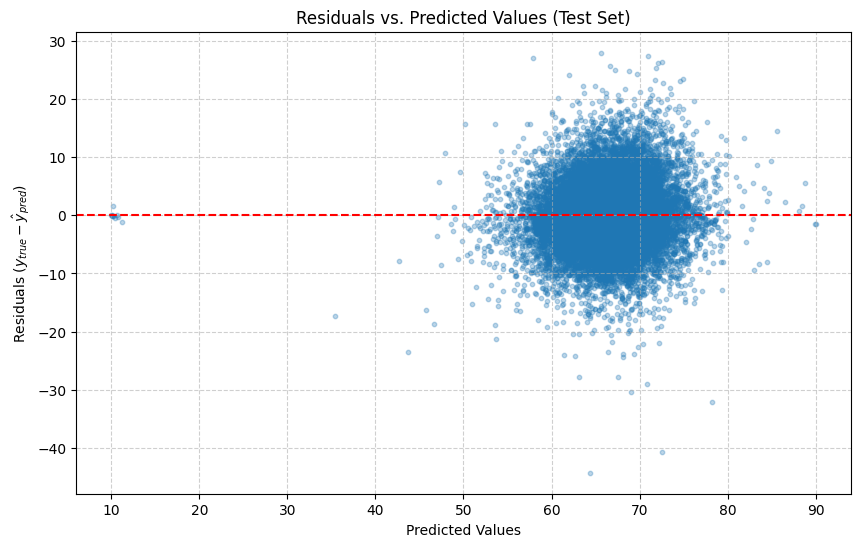

In [8]:
# --- Plot Residuals vs. Predicted Values (untuk Test Set) ---
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test, residuals_test, alpha=0.3, s=10)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals ($y_{true} - \hat{y}_{pred}$)")
plt.title("Residuals vs. Predicted Values (Test Set)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

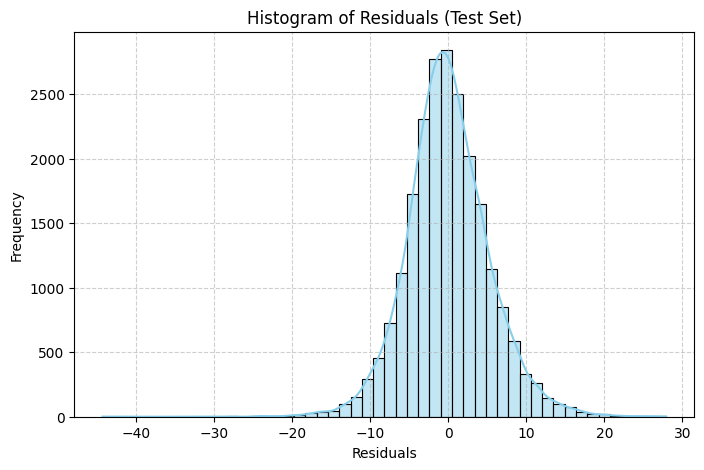

In [11]:
# --- Histogram Residuals (untuk Test Set) ---
plt.figure(figsize=(8, 5))
sns.histplot(residuals_test, kde=True, bins=50, color='skyblue')
plt.title("Histogram of Residuals (Test Set)")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<Figure size 800x500 with 0 Axes>

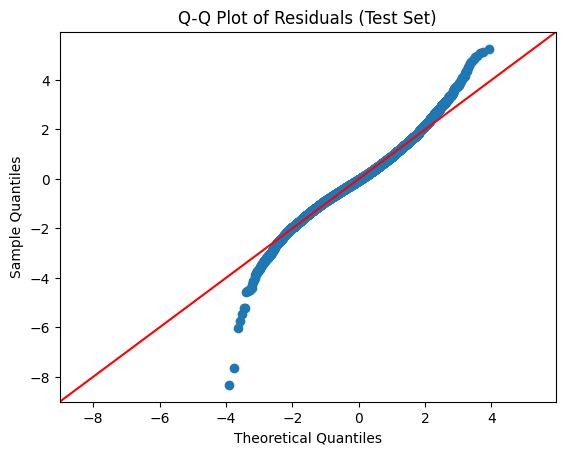

In [16]:
# --- Q-Q Plot Residuals (untuk Test Set) ---
import statsmodels.api as sm

plt.figure(figsize=(8, 5))
sm.qqplot(residuals_test, line='45', fit=True)
plt.title("Q-Q Plot of Residuals (Test Set)")
plt.show()

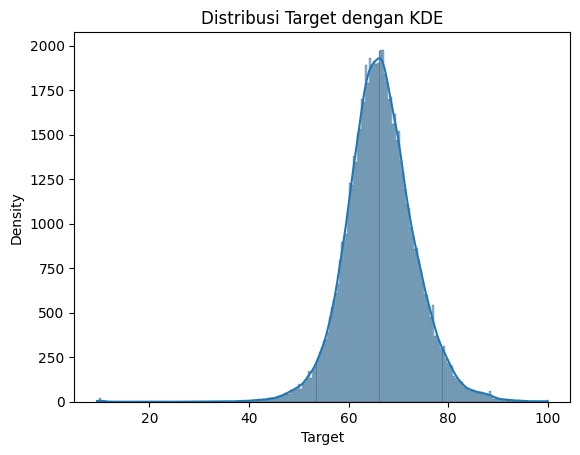

In [18]:
sns.histplot(y, kde=True)
plt.title("Distribusi Target dengan KDE")
plt.xlabel("Target")
plt.ylabel("Density")
plt.show()

In [20]:
from scipy.stats import skew, kurtosis

print("Skewness:", skew(y))
print("Kurtosis:", kurtosis(y))

Skewness: -0.06345868237345477
Kurtosis: 2.6546013040035916


In [24]:
from sklearn.feature_selection import SelectKBest, f_regression

# Pilih K fitur terbaik dengan uji F (ANOVA) untuk regresi
selector = SelectKBest(score_func=f_regression, k=100)
X_selected = selector.fit_transform(X, y)

# Untuk lihat fitur mana yang terpilih
mask = selector.get_support()
selected_feature_names = X.columns[mask]
# print("Fitur terpilih:", selected_feature_names)


In [25]:
model_gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
model_gbr.fit(X_train[selected_feature_names], y_train, sample_weight=weight_train)

y_pred_gbr = model_gbr.predict(X_test[selected_feature_names])

r2_gbr = r2_score(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)

# Tampilkan hasil
print(f"R² Score : {r2_gbr:.4f}")
print(f"MSE      : {mse_gbr:.4f}")
print(f"RMSE     : {rmse_gbr:.4f}")
print(f"MAE      : {mae_gbr:.4f}")

R² Score : 0.3695
MSE      : 30.4446
RMSE     : 5.5177
MAE      : 4.2173


In [23]:
model_gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
model_gbr.fit(X_train, y_train, sample_weight=weight_train)

y_pred_gbr = model_gbr.predict(X_test)

r2_gbr = r2_score(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)

# Tampilkan hasil
print(f"R² Score : {r2_gbr:.4f}")
print(f"MSE      : {mse_gbr:.4f}")
print(f"RMSE     : {rmse_gbr:.4f}")
print(f"MAE      : {mae_gbr:.4f}")

R² Score : 0.3864
MSE      : 29.6269
RMSE     : 5.4431
MAE      : 4.1485


In [28]:
# Robust Regression
model_hg = HuberRegressor()
model_hg.fit(X_train, y_train)

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_huber.py:342: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


HuberRegressor()

In [ ]:
y_pred_hg = model_hg.predict(X_test)

r2_hg = r2_score(y_test, y_pred_hg)
mse_hg = mean_squared_error(y_test, y_pred_hg)
rmse_hg = np.sqrt(mse_hg)
mae_hg = mean_absolute_error(y_test, y_pred_hg)


print(f"R² Score : {r2_hg:.4f}")
print(f"MSE      : {mse_hg:.4f}")
print(f"RMSE     : {rmse_hg:.4f}")
print(f"MAE      : {mae_hg:.4f}")
print("Coef:", model_hg.coef_)
print("Intercept:", model_hg.intercept_)

R² Score : 0.3816
MSE      : 29.8589
RMSE     : 5.4643
MAE      : 4.1594
Coef: [-2.81016358e-01 -2.34805932e-01  1.99712906e-01 -1.76072436e-01
 -2.08066636e-01  2.58649975e-01  4.10617058e-02  2.70201706e-01
  1.31261455e-01 -2.68292759e-01  7.69347653e-02 -3.80229015e-02
  2.33421469e-01  8.68315295e-02 -3.11867833e-01 -8.25195593e-02
 -1.35275061e-01 -1.74118934e-01 -1.38185764e-01 -6.37861976e-01
 -3.90316748e-02  6.69362726e-02  9.83292285e-01 -3.89103729e-01
  2.22898526e-02  7.90894588e-02 -7.43469375e-03  1.81056024e-01
 -2.24935843e-01  6.93420002e-02  1.38650828e-01 -1.62424894e-01
  1.49091758e-02 -5.64970301e-03 -1.48763040e-02 -1.02933889e-01
 -2.11245078e-01 -3.11547595e-01  2.45641767e-02  1.65748839e-01
 -1.67714731e-02  6.95114285e-02 -1.60357840e-01 -4.90571708e-01
 -6.67450108e-02 -3.05300468e-03  2.40474278e-01 -3.31298188e-01
 -5.15427583e-02 -2.92412675e-02  4.94968646e-02  1.76991153e-03
 -4.02532160e-02 -2.58540860e-02 -6.03320028e-02  1.41789822e-02
  2.8909075

In [34]:
model_hg2 = HuberRegressor(
    epsilon=1.35,
    max_iter=1000,
    alpha=0.0001,
    fit_intercept=True,
    warm_start=True 
)

In [35]:
model_hg2.fit(X_train, y_train)

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_huber.py:342: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


HuberRegressor(max_iter=1000, warm_start=True)

In [36]:
y_pred_hg2 = model_hg2.predict(X_test)

r2_hg2 = r2_score(y_test, y_pred_hg2)
mse_hg2 = mean_squared_error(y_test, y_pred_hg2)
rmse_hg2 = np.sqrt(mse_hg2)
mae_hg2 = mean_absolute_error(y_test, y_pred_hg2)


print(f"R² Score : {r2_hg2:.4f}")
print(f"MSE      : {mse_hg2:.4f}")
print(f"RMSE     : {rmse_hg2:.4f}")
print(f"MAE      : {mae_hg2:.4f}")
print("Coef:", model_hg2.coef_)
print("Intercept:", model_hg2.intercept_)

R² Score : 0.3781
MSE      : 30.0290
RMSE     : 5.4799
MAE      : 4.1714
Coef: [-2.95212310e-01 -2.48344943e-01  2.04745103e-01 -1.86051405e-01
 -2.04934162e-01  2.62577530e-01  3.64021117e-02  2.74096819e-01
  1.29672436e-01 -2.66247215e-01  7.64475183e-02 -3.83869107e-02
  2.31278493e-01  8.54793104e-02 -3.12474713e-01 -7.69533319e-02
 -1.43568711e-01 -1.78389124e-01 -1.41664753e-01 -6.29615502e-01
 -3.84819597e-02  7.60077653e-02  9.91516350e-01 -3.90979699e-01
  3.57066344e-02  7.54148949e-02  8.82882982e-04  1.81277629e-01
 -2.25908056e-01  6.94752668e-02  1.33978848e-01 -1.73242430e-01
  8.36167267e-03  5.55086210e-03 -2.15482984e-02 -1.04978203e-01
 -2.07978666e-01 -3.22527499e-01  2.27619165e-02  1.63458710e-01
 -5.75901182e-02  1.02266359e-01 -1.80534595e-01 -4.78906685e-01
 -5.10253563e-02 -3.36641512e-02  2.53610603e-01 -5.29228069e-01
 -5.26039480e-02 -3.16410626e-02  4.74892345e-02 -4.10491876e-03
 -4.28043310e-02 -2.64817508e-02 -6.15067591e-02  1.72490830e-02
  2.9672683

In [ ]:
# SHAP explanation
import shap
explainer = shap.Explainer(model_gbr.predict, X_train)  # model.predict for tree-based regressor
shap_values = explainer(X_test)
# Plot summary
shap.summary_plot(shap_values, X_test)